# Northwind database: SQL

## Setting up

The following cells are to set up the environment for using SQL commands within Python IDE. Run the two cells below without changing anything.

the code below will download locally the northwind database-- this will take a while, so plz be patient. You only need to do this once, as after running it, the database will be in your harddrive



In [ ]:
%%capture
# Clone the Northwind SQLite3 sample database repository
!git clone https://github.com/jpwhite3/northwind-SQLite3.git

# Build the Northwind SQLite database using the system's default sqlite3
%cd northwind-SQLite3/
!make build
%cd ..



![](norhwind-schema.png)

In [8]:
import sqlite3 as sql # library for implementing SQL commands
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

from sklearn.utils.fixes import pd
conn = sql.connect("northwind-SQLite3/dist/northwind.db") # connecting Northwind dataset to SQL


pd.set_option('display.max_rows', None) # display all rows instead of just the head and the tail

def database_summary(conn):
    # Get all table names in the SQLite database
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table'",
        conn
    )['name']

    # Build a list of small DataFrames: one per table
    summary_frames = []
    for table in tables:
        count = pd.read_sql_query(
            f'SELECT COUNT(*) AS n FROM "{table}"',
            conn
        ).iloc[0, 0]
        summary_frames.append(
            pd.DataFrame({
                "Table Name": [table],
                "Record Count": [count]
            })
        )

    # Concatenate into a single summary DataFrame
    summary = pd.concat(summary_frames, ignore_index=True)
    return summary


def display_query(query, connection):
    cur = connection.cursor()
    cur.execute(query)
    
    # Get column headers
    headers = [description[0] for description in cur.description]
    
    # Print headers with some spacing
    print(f"{' | '.join(headers)}")
    
    # Print rows
    for row in cur.fetchall():
        print(row)


## Displaying summary of the database

Simply run ```database_summary()``` to retrieve the names of tables and the number of rows at any time. This is useful to keep track of any new table you've created throughout the exercise.

In [3]:
# Use the helper function defined earlier to show a summary
# of all tables in the database (table name + row count).
database_summary(conn)

# Query SQLite's internal sqlite_master table to get the names
# of all user-defined tables in the database, ordered by name.
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name;",
    conn
)
tables  # Display the resulting DataFrame of table names

# Extract just the 'name' column as a pandas Series so we can
# iterate over the table names easily in a for-loop.
table_names = tables['name']

# Loop over each table name and display its schema (column definitions).
for t in table_names:
    # Print a header showing which table's schema is being displayed.
    print(f"\n=== {t} ===")
    # Use SQLite's PRAGMA table_info to get column details (name, type, etc.)
    # for the current table, and display the result as a DataFrame.
    display(pd.read_sql(f'PRAGMA table_info("{t}");', conn))





=== Categories ===


,cid,name,type,notnull,dflt_value,pk
0,0,CategoryID,INTEGER,0,None,1
1,1,CategoryName,TEXT,0,None,0
2,2,Description,TEXT,0,None,0
3,3,Picture,BLOB,0,None,0



=== CustomerCustomerDemo ===


,cid,name,type,notnull,dflt_value,pk
0,0,CustomerID,TEXT,1,None,1
1,1,CustomerTypeID,TEXT,1,None,2



=== CustomerDemographics ===


...

,cid,name,type,notnull,dflt_value,pk
0,0,SupplierID,INTEGER,1,None,1
1,1,CompanyName,TEXT,1,None,0
2,2,ContactName,TEXT,0,None,0
3,3,ContactTitle,TEXT,0,None,0
4,4,Address,TEXT,0,None,0
5,5,City,TEXT,0,None,0
6,6,Region,TEXT,0,None,0
7,7,PostalCode,TEXT,0,None,0
8,8,Country,TEXT,0,None,0
9,9,Phone,TEXT,0,None,0



=== Territories ===


,cid,name,type,notnull,dflt_value,pk
0,0,TerritoryID,TEXT,1,None,1
1,1,TerritoryDescription,TEXT,1,None,0
2,2,RegionID,INTEGER,1,None,0



=== sqlite_sequence ===


,cid,name,type,notnull,dflt_value,pk
0,0,name,,0,None,0
1,1,seq,,0,None,0


## Displaying results from SQL queries

Now for every task, create a new cell with the following format and simply specify the ```sql_query``` argument with the actual SQL command you want.


In [7]:
# Define a SQL query as a multi‑line string (triple quotes allow line breaks)
sql_query = '''
SELECT *
FROM Customers
LIMIT 20;
'''

# Use pandas to run the SQL query on the database connection 'conn'
# and return the results as a DataFrame called 'df'
df = pd.read_sql_query(sql_query, conn)

# Display the DataFrame so you can see the first 20 rows of the Customers table
df

,CustomerID,CompanyName,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax
0,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,Western Europe,12209,Germany,030-0074321,030-0076545
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,Central America,05021,Mexico,(5) 555-4729,(5) 555-3745
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,Central America,05023,Mexico,(5) 555-3932,None
3,AROUT,Around the Horn,Thomas Hardy,Sales Representative,120 Hanover Sq.,London,British Isles,WA1 1DP,UK,(171) 555-7788,(171) 555-6750
4,BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Berguvsvägen 8,Luleå,Northern Europe,S-958 22,Sweden,0921-12 34 65,0921-12 34 67
5,BLAUS,Blauer See Delikatessen,Hanna Moos,Sales Representative,Forsterstr. 57,Mannheim,Western Europe,68306,Germany,0621-08460,0621-08924
6,BLONP,Blondesddsl père et fils,Frédérique Citeaux,Marketing Manager,"24, place Kléber",Strasbourg,Western Europe,67000,France,88.60.15.31,88.60.15.32
7,BOLID,Bólido Comidas preparadas,Martín Sommer,Owner,"C/ Araquil, 67",Madrid,Southern Europe,28023,Spain,(91) 555 22 82,(91) 555 91 99
8,BONAP,Bon app',Laurence Lebihan,Owner,"12, rue des Bouchers",Marseille,Western Europe,13008,France,91.24.45.40,91.24.45.41
9,BOTTM,Bottom-Dollar Markets,Elizabeth Lincoln,Accounting Manager,23 Tsawassen Blvd.,Tsawassen,North America,T2F 8M4,Canada,(604) 555-4729,(604) 555-3745


In [ ]:
# a table that shows customer id, company name, and country, where 
# country is Germany, and limit the number of rows to 10

sql_query = """
SELECT
    CustomerID,
    CompanyName,
    Country
FROM Customers
WHERE Country = 'Germany'
LIMIT 10;
"""

df = pd.read_sql_query(sql_query, conn)
df

,CustomerID,CompanyName,Country
0,ALFKI,Alfreds Futterkiste,Germany
1,BLAUS,Blauer See Delikatessen,Germany
2,DRACD,Drachenblut Delikatessen,Germany
3,FRANK,Frankenversand,Germany
4,KOENE,Königlich Essen,Germany
5,LEHMS,Lehmanns Marktstand,Germany
6,MORGK,Morgenstern Gesundkost,Germany
7,OTTIK,Ottilies Käseladen,Germany
8,QUICK,QUICK-Stop,Germany
9,TOMSP,Toms Spezialitäten,Germany


In [26]:
# What if we only want the price of products? 

sql_query = """
SELECT
    UnitPrice
FROM Products
LIMIT 10;
"""

df = pd.read_sql_query(sql_query, conn)
df


# What if we want to get the price of products and the company name of the supplier? 

sql_query = """
SELECT
    ProductName,
    PRODUCTID,
    UnitPrice,
    unitsinstock,
    reorderlevel
FROM Products
LIMIT 10;
"""

df = pd.read_sql_query(sql_query, conn)
df


,ProductName,ProductID,UnitPrice,UnitsInStock,ReorderLevel
0,Chai,1,18.00,39,10
1,Chang,2,19.00,17,25
2,Aniseed Syrup,3,10.00,13,25
3,Chef Anton's Cajun Seasoning,4,22.00,53,0
4,Chef Anton's Gumbo Mix,5,21.35,0,0
5,Grandma's Boysenberry Spread,6,25.00,120,25
6,Uncle Bob's Organic Dried Pears,7,30.00,15,10
7,Northwoods Cranberry Sauce,8,40.00,6,0
8,Mishi Kobe Niku,9,97.00,29,0
9,Ikura,10,31.00,31,0


In [10]:
# Let’s find the cheap products (say price < $25).
#  Now we don’t want all rows---just ten of them. 

sql_query = """
SELECT *
FROM Products
WHERE UnitPrice < 25
LIMIT 10;
"""

df = pd.read_sql_query(sql_query, conn)
df

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1
5,11,Queso Cabrales,5,4,1 kg pkg.,21.00,22,30,30,0
6,13,Konbu,6,8,2 kg box,6.00,24,0,5,0
7,14,Tofu,6,7,40 - 100 g pkgs.,23.25,35,0,0,0
8,15,Genen Shouyu,6,2,24 - 250 ml bottles,15.50,39,0,5,0
9,16,Pavlova,7,3,32 - 500 g boxes,17.45,29,0,10,0


In [11]:
# List out each row in Products table where UnitPrice is greater than or equal to $30 (returning all columns)

sql_query = """
SELECT *
FROM Products
WHERE UnitPrice >= 30
"""

df = pd.read_sql_query(sql_query, conn)
df

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,7,Uncle Bob's Organic Dried Pears,3,7,12 - 1 lb pkgs.,30.00,15,0,10,0
1,8,Northwoods Cranberry Sauce,3,2,12 - 12 oz jars,40.00,6,0,0,0
2,9,Mishi Kobe Niku,4,6,18 - 500 g pkgs.,97.00,29,0,0,1
3,10,Ikura,4,8,12 - 200 ml jars,31.00,31,0,0,0
4,12,Queso Manchego La Pastora,5,4,10 - 500 g pkgs.,38.00,86,0,0,0
5,17,Alice Mutton,7,6,20 - 1 kg tins,39.00,0,0,0,1
6,18,Carnarvon Tigers,7,8,16 kg pkg.,62.50,42,0,0,0
7,20,Sir Rodney's Marmalade,8,3,30 gift boxes,81.00,40,0,0,0
8,26,Gumbär Gummibärchen,11,3,100 - 250 g bags,31.23,15,0,0,0
9,27,Schoggi Schokolade,11,3,100 - 100 g pieces,43.90,49,0,30,0


In [12]:
# How about products less than $10 but greater than $5 (returning product names & prices only)?
sql_query = """
SELECT ProductName, UnitPrice
FROM Products
WHERE UnitPrice BETWEEN 5 AND 10
"""

df = pd.read_sql_query(sql_query, conn)
df

,ProductName,UnitPrice
0,Aniseed Syrup,10.00
1,Konbu,6.00
2,Teatime Chocolate Biscuits,9.20
3,Sir Rodney's Scones,10.00
4,Tunnbröd,9.00
5,Jack's New England Clam Chowder,9.65
6,Rogede sild,9.50
7,Zaanse koeken,9.50
8,Filo Mix,7.00
9,Tourtière,7.45


In [15]:
# we can name the output as num_products
sql_query = """
SELECT 
COUNT(*) 
FROM Products 
WHERE UnitPrice < 10;
"""

df = pd.read_sql_query(sql_query, conn)
df

,COUNT(*)
0,11


In [17]:
# How many products have a price less than $10?

sql_query = """
SELECT COUNT(*) AS Num_Products
FROM Products
WHERE UnitPrice < 10
"""

df = pd.read_sql_query(sql_query, conn)
df



,Num_Products
0,11


In [18]:
# What’s the total dollar value of inventory? (UnitPrice * UnitsInStock)

sql_query = """
SELECT SUM(UnitPrice * UnitsInStock) AS Total_Value
FROM Products
"""

df = pd.read_sql_query(sql_query, conn)
df


,Total_Value
0,74050.85


In [59]:
# list products in ascending order of price

sql_query = """
SELECT * 
FROM Products
ORDER BY UnitPrice ASC;
"""

df = pd.read_sql_query(sql_query, conn)
df

# list products in descending order of price

sql_query = """
SELECT * 
FROM Products
ORDER BY UnitPrice DESC;
"""

df = pd.read_sql_query(sql_query, conn)
df

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,38,Côte de Blaye,18,1,12 - 75 cl bottles,263.50,17,0,15,0
1,29,Thüringer Rostbratwurst,12,6,50 bags x 30 sausgs.,123.79,0,0,0,1
2,9,Mishi Kobe Niku,4,6,18 - 500 g pkgs.,97.00,29,0,0,1
3,20,Sir Rodney's Marmalade,8,3,30 gift boxes,81.00,40,0,0,0
4,18,Carnarvon Tigers,7,8,16 kg pkg.,62.50,42,0,0,0
5,59,Raclette Courdavault,28,4,5 kg pkg.,55.00,79,0,0,0
6,51,Manjimup Dried Apples,24,7,50 - 300 g pkgs.,53.00,20,0,10,0
7,62,Tarte au sucre,29,3,48 pies,49.30,17,0,0,0
8,43,Ipoh Coffee,20,1,16 - 500 g tins,46.00,17,10,25,0
9,28,Rössle Sauerkraut,12,7,25 - 825 g cans,45.60,26,0,0,1


In [21]:
# create a new column, NewPrice, that is 10% higher than the UnitPrice 

sql_query = """
SELECT *, 
    UnitPrice * 1.10 AS NewPrice 
FROM Products 
LIMIT 20
"""

df = pd.read_sql_query(sql_query, conn)
df

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,NewPrice
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,19.800
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,20.900
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,11.000
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,24.200
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,23.485
5,6,Grandma's Boysenberry Spread,3,2,12 - 8 oz jars,25.00,120,0,25,0,27.500
6,7,Uncle Bob's Organic Dried Pears,3,7,12 - 1 lb pkgs.,30.00,15,0,10,0,33.000
7,8,Northwoods Cranberry Sauce,3,2,12 - 12 oz jars,40.00,6,0,0,0,44.000
8,9,Mishi Kobe Niku,4,6,18 - 500 g pkgs.,97.00,29,0,0,1,106.700
9,10,Ikura,4,8,12 - 200 ml jars,31.00,31,0,0,0,34.100


In [22]:
# count products by category

sql_query = """
SELECT 
  CategoryID, 
  COUNT(*) AS NumProducts
FROM Products
GROUP BY CategoryID; 
"""

df = pd.read_sql_query(sql_query, conn)
df

,CategoryID,NumProducts
0,1,12
1,2,12
2,3,13
3,4,10
4,5,7
5,6,6
6,7,5
7,8,12


In [25]:
sql_query = """
SELECT *, 
CASE WHEN UnitPrice < 10 
   THEN 't'
   ELSE 'f' END AS Cheap
FROM Products 
LIMIT 20
"""

df = pd.read_sql_query(sql_query, conn)
df


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,Cheap
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,f
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,f
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,f
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,f
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,f
5,6,Grandma's Boysenberry Spread,3,2,12 - 8 oz jars,25.00,120,0,25,0,f
6,7,Uncle Bob's Organic Dried Pears,3,7,12 - 1 lb pkgs.,30.00,15,0,10,0,f
7,8,Northwoods Cranberry Sauce,3,2,12 - 12 oz jars,40.00,6,0,0,0,f
8,9,Mishi Kobe Niku,4,6,18 - 500 g pkgs.,97.00,29,0,0,1,f
9,10,Ikura,4,8,12 - 200 ml jars,31.00,31,0,0,0,f


ON YOUR OWN

- Create a new table called ProductPriceClass with all of the products in the Products table but with only the following columns: ProductName, UnitPrice, and Cheap
- If the price of a product is less than $10, the value of Cheap should be set to ‘t’; if it’s not less than $10, Cheap should be set to ‘f’
- The records should be sorted by UnitPrice in ascending order.

In [26]:
# 1.This will create a new table in the database
create_table_sql = """
CREATE TABLE ProductPriceClass AS
SELECT 
    ProductName, 
    UnitPrice, 
    CASE 
        WHEN UnitPrice < 10 THEN 't' 
        ELSE 'f' 
    END AS Cheap
FROM Products
ORDER BY UnitPrice ASC;
"""

# This will select the new table and return everything from it
select_sql = "SELECT * FROM ProductPriceClass"

# 2. Execute the creation (The "Action" Step)
# We use a cursor to execute the SQL command
cur = conn.cursor()
cur.execute("DROP TABLE IF EXISTS ProductPriceClass") # Good practice: prevents error if you run cell twice
cur.execute(create_table_sql)
conn.commit() # Important: Saves the change to the database file
cur.close()

# 3. Read the result (The "Data" Step)
df = pd.read_sql_query(select_sql, conn)
df


,ProductName,UnitPrice,Cheap
0,Geitost,2.50,t
1,Guaraná Fantástica,4.50,t
2,Konbu,6.00,t
3,Filo Mix,7.00,t
4,Tourtière,7.45,t
5,Rhönbräu Klosterbier,7.75,t
6,Tunnbröd,9.00,t
7,Teatime Chocolate Biscuits,9.20,t
8,Rogede sild,9.50,t
9,Zaanse koeken,9.50,t


In [ ]:
# Just select the data directly, without creating a new table in the database
sql_query = """
SELECT 
    ProductName, 
    UnitPrice, 
    CASE 
        WHEN UnitPrice < 10 THEN 't' 
        ELSE 'f' 
    END AS Cheap
FROM Products
ORDER BY UnitPrice ASC;
"""

df = pd.read_sql_query(sql_query, conn)
df

,ProductName,UnitPrice,Cheap
0,Geitost,2.50,t
1,Guaraná Fantástica,4.50,t
2,Konbu,6.00,t
3,Filo Mix,7.00,t
4,Tourtière,7.45,t
5,Rhönbräu Klosterbier,7.75,t
6,Tunnbröd,9.00,t
7,Teatime Chocolate Biscuits,9.20,t
8,Rogede sild,9.50,t
9,Zaanse koeken,9.50,t


Group rows together by the value in Cheap and then count the rows by group

In [ ]:
# Group rows together by the value in Cheap and then count the rows by group-- 
# how many cheap and how many expensive products

sql_query = """
SELECT 
    Cheap,
    COUNT(*) AS Count
FROM ProductPriceClass
GROUP BY Cheap;
"""

df = pd.read_sql_query(sql_query, conn)
df

,Cheap,Count
0,f,66
1,t,11


What is the average, min and max price per product, by group?

Hint:  You can use other functions besides COUNT (google them).
Hint: can you figure out how to round the avg price to two decimal places?



In [29]:
sql_query = """
SELECT 
    Cheap,
    ROUND(AVG(UnitPrice), 4) AS AvgPriceRounded,
    MIN(UnitPrice) AS MinPrice,
    MAX(UnitPrice) AS MaxPrice
FROM ProductPriceClass
GROUP BY Cheap;
"""

df = pd.read_sql_query(sql_query, conn)
df

,Cheap,AvgPriceRounded,MinPrice,MaxPrice
0,f,32.4342,10.0,263.50
1,t,7.4591,2.5,9.65


**Split- Apply- Combine**

What if we want to group by customerID (*split* the data by customerID),
and then for each customer, we want to calculate the total amount they spent (*apply*),
and then combine the results (*combine*)

In [ ]:
# Group by customerID (*split* the data by customerID),
# and then for each customer, we want to calculate the total amount they spent (*apply*),
# and then combine the results (*combine*)

sql_query = """
SELECT 
  CustomerId, 
  COUNT(*) AS NumOrders 
FROM Orders
GROUP BY CustomerId 
ORDER BY NumOrders DESC;   
"""

df = pd.read_sql_query(sql_query, conn)
df  

,CustomerID,NumOrders
0,SAVEA,31
1,ERNSH,30
2,QUICK,28
3,HUNGO,19
4,FOLKO,19
5,RATTC,18
6,HILAA,18
7,BERGS,18
8,BONAP,17
9,WARTH,15


In [30]:
sql_query = """
SELECT  * FROM orders
LIMIT 20;
"""
df = pd.read_sql_query(sql_query, conn)
df

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l-Abbaye,Reims,Western Europe,51100,France
1,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,Western Europe,44087,Germany
2,10250,HANAR,4,2016-07-08,2016-08-05,2016-07-12,2,65.83,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,South America,05454-876,Brazil
3,10251,VICTE,3,2016-07-08,2016-08-05,2016-07-15,1,41.34,Victuailles en stock,"2, rue du Commerce",Lyon,Western Europe,69004,France
4,10252,SUPRD,4,2016-07-09,2016-08-06,2016-07-11,2,51.30,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,Western Europe,B-6000,Belgium
5,10253,HANAR,3,2016-07-10,2016-07-24,2016-07-16,2,58.17,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,South America,05454-876,Brazil
6,10254,CHOPS,5,2016-07-11,2016-08-08,2016-07-23,2,22.98,Chop-suey Chinese,Hauptstr. 31,Bern,Western Europe,3012,Switzerland
7,10255,RICSU,9,2016-07-12,2016-08-09,2016-07-15,3,148.33,Richter Supermarkt,Starenweg 5,Genève,Western Europe,1204,Switzerland
8,10256,WELLI,3,2016-07-15,2016-08-12,2016-07-17,2,13.97,Wellington Importadora,"Rua do Mercado, 12",Resende,South America,08737-363,Brazil
9,10257,HILAA,4,2016-07-16,2016-08-13,2016-07-22,3,81.91,HILARION-Abastos,Carrera 22 con Ave. Carlos Soublette #8-35,San Cristóbal,South America,5022,Venezuela


In [31]:

sql_query = """
SELECT  * FROM customers
LIMIT 20;
"""

df = pd.read_sql_query(sql_query, conn)
df

,CustomerID,CompanyName,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax
0,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,Western Europe,12209,Germany,030-0074321,030-0076545
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,Central America,05021,Mexico,(5) 555-4729,(5) 555-3745
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,Central America,05023,Mexico,(5) 555-3932,None
3,AROUT,Around the Horn,Thomas Hardy,Sales Representative,120 Hanover Sq.,London,British Isles,WA1 1DP,UK,(171) 555-7788,(171) 555-6750
4,BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Berguvsvägen 8,Luleå,Northern Europe,S-958 22,Sweden,0921-12 34 65,0921-12 34 67
5,BLAUS,Blauer See Delikatessen,Hanna Moos,Sales Representative,Forsterstr. 57,Mannheim,Western Europe,68306,Germany,0621-08460,0621-08924
6,BLONP,Blondesddsl père et fils,Frédérique Citeaux,Marketing Manager,"24, place Kléber",Strasbourg,Western Europe,67000,France,88.60.15.31,88.60.15.32
7,BOLID,Bólido Comidas preparadas,Martín Sommer,Owner,"C/ Araquil, 67",Madrid,Southern Europe,28023,Spain,(91) 555 22 82,(91) 555 91 99
8,BONAP,Bon app',Laurence Lebihan,Owner,"12, rue des Bouchers",Marseille,Western Europe,13008,France,91.24.45.40,91.24.45.41
9,BOTTM,Bottom-Dollar Markets,Elizabeth Lincoln,Accounting Manager,23 Tsawassen Blvd.,Tsawassen,North America,T2F 8M4,Canada,(604) 555-4729,(604) 555-3745


In [31]:
# using aliases
sql_query = """
SELECT 
o.OrderID, 
c.Country
FROM Orders AS o
LEFT JOIN Customers AS c 
ON o.CustomerID = c.CustomerID
LIMIT 20;
"""

df = pd.read_sql_query(sql_query, conn)
df

,OrderID,Country
0,10248,France
1,10249,Germany
2,10250,Brazil
3,10251,France
4,10252,Belgium
5,10253,Brazil
6,10254,Switzerland
7,10255,Switzerland
8,10256,Brazil
9,10257,Venezuela


In [ ]:



# without aliases - more typing!
sql_query = """
SELECT 
    Orders.OrderID, 
    Customers.Country
FROM Orders
LEFT JOIN Customers 
ON Orders.CustomerID = Customers.CustomerID
LIMIT 20; 
"""

df = pd.read_sql_query(sql_query, conn)
df

In [32]:
sql_query = """
SELECT Country, COUNT(*) AS NumOrders
FROM
(SELECT c.Country, o.OrderID
FROM Orders AS o 
LEFT JOIN Customers AS c 
ON o.CustomerID = c.CustomerID)
GROUP BY Country 
ORDER BY NumOrders DESC;  
"""

df = pd.read_sql_query(sql_query, conn)
df


,Country,NumOrders
0,USA,122
1,Germany,122
2,Brazil,83
3,France,77
4,UK,56
5,Venezuela,46
6,Austria,40
7,Sweden,37
8,Canada,30
9,Mexico,28


# Question 1: Understanding employee performance in timely shipping
**Note:** This section is to be completed in `pandas`.

Some of Northwind's customers are complaining that shipments are arriving much later than they should, claiming that the "shipping date" was later than the "required date". To get to the bottom of this, use the data in the `Orders` tab and write code to answer the following:
1. What percentage of all shipments are shipped after the required date (we'll call these late shipments)?
  * **Hint:** You can use the `>` operator to compare dates. To get the percentage of true values, you can take the `.mean()` of a series of Booleans, because a `True` value is interpreted as `1`, and a `False` value is interpreted as `0`.

2. For each employee, what percentage of the orders processed by the employee are late (i.e. the late shipment rate)? Report this in two ways:

  1. Printing a dataframe showing the employee ID and percentage of late shipments
    * **Hint:** You can use the `.groupby(COLUMN_NAME)` method on a dataframe to aggregate a computation by the values of a given column. For example, `df.groupby("EmployeeID")["Freight"].mean()` would give the average freight per employee ID.

  2. A bar plot, showing the late shipment rate of each employee in descending order from left to right. Make sure to:

  
    * Label the x- and y-axis
    * Title your plot "Late shipment rate, by employee"
    * **Hint:** The `.sort_values()` method of a dataframe will be useful here. To generate a bar plot, use the `.plot()` method of a dataframe with `kind="bar"`. We've imported `matplotlib.pyplot` for you as `plt`, so you can use `plt.ylabel()` and `plt.title()` to label your y-axis and plot.

   EmployeeID    IsLate
0           9  0.093023
1           4  0.064103
2           7  0.055556
3           6  0.044776
4           2  0.041667
5           3  0.039370
6           8  0.038462
7           5  0.023810
8           1  0.016260


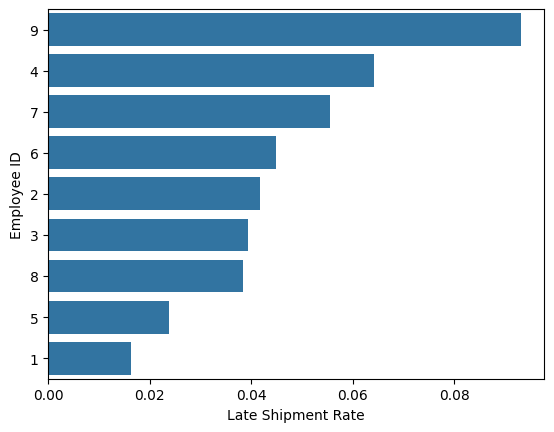

In [ ]:
# Question 1: Understanding employee performance in timely shipping


# Connect to the database and load the orders table
orders = pd.read_sql("SELECT * FROM Orders", conn)


# 1. Percentage of all shipments that are late

# Convert date columns to datetime objects to ensure correct comparison
orders['ShippedDate'] = pd.to_datetime(orders['ShippedDate'])
orders['RequiredDate'] = pd.to_datetime(orders['RequiredDate'])


# 2. Late shipment rate per employee
# Create a boolean series for late shipments
orders['IsLate'] = orders['ShippedDate'] > orders['RequiredDate']

# Recalculate late shipments and sort the rates for the plot
late_rates = (orders
    .groupby("EmployeeID")["IsLate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(late_rates)



# 2.2 Bar plot in descending order

# Correctly plot using the sorted Series index and values
sns.barplot(data = late_rates, 
x="IsLate", 
y=late_rates["EmployeeID"].astype(str))

plt.xlabel("Late Shipment Rate")
plt.ylabel("Employee ID")

plt.show()


# Question 2: Logistics Issues
1. Take a look at the `Orders` and `Orders Details` tabs of the Northwind spreadsheet. What does each sheet describe, and how are they related? 

2. There's been a disruption in the logistics sector, and Northwind is no longer able to import products from the USA and Canada. Combining data in the `Product`, `Orders Details`, and `Suppliers` sheets, write code to answer the following:
   1. How many suppliers are affected by this disruption?

   2. How many products are made by the suppliers in these countries?

   3. How many products are affected in each `CategoryID`?

   4. If we define revenue as `UnitPrice * Quantity * (1-Discount)`, how much of Northwind's historical revenue has been from items affected by this disruption?



3. Extending the answer to question 2.2.4 above:
   1. Write code that prints the statement `The total historical revenue generated by products from {COUNTRY} is {sum of historical revenue}` for each country.

   2. Generate a bar chart showing the contribution of each country's products to the total historical revenue of Northwind. Biggest revenue generating country should be at the top

Orders Table:


,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l-Abbaye,Reims,Western Europe,51100,France
1,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,Western Europe,44087,Germany
2,10250,HANAR,4,2016-07-08,2016-08-05,2016-07-12,2,65.83,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,South America,05454-876,Brazil
3,10251,VICTE,3,2016-07-08,2016-08-05,2016-07-15,1,41.34,Victuailles en stock,"2, rue du Commerce",Lyon,Western Europe,69004,France
4,10252,SUPRD,4,2016-07-09,2016-08-06,2016-07-11,2,51.30,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,Western Europe,B-6000,Belgium



Order Details Table:


,OrderID,ProductID,UnitPrice,Quantity,Discount
0,10248,11,14.0,12,0.0
1,10248,42,9.8,10,0.0
2,10248,72,34.8,5,0.0
3,10249,14,18.6,9,0.0
4,10249,51,42.4,40,0.0


Affected suppliers: 6
Affected products: 16


,CategoryID,AffectedProductCount
0,1,3
1,2,7
2,3,1
3,6,2
4,7,1
5,8,2


Total affected historical revenue: $205,845.67


,Country,TotalRevenue
0,France,277554.1300
1,Germany,197450.0165
2,Australia,172086.5455
3,USA,122103.4650
4,Italy,98479.7750
5,Canada,83742.2075
6,UK,78432.0400
7,Japan,45263.0950
8,Norway,43141.5100
9,Singapore,42017.6450


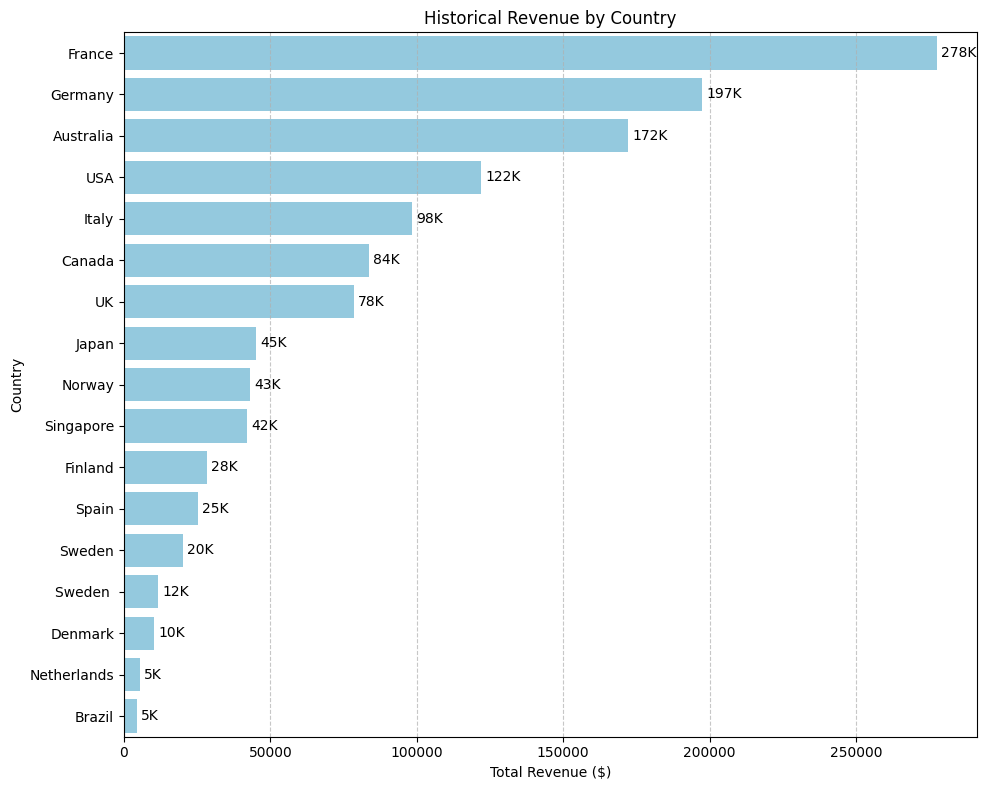

In [39]:
# Question 2: Logistics Issues


# Question 2: Logistics Issues
# 1. Take a look at the `Orders` and `Orders Details` tabs of the Northwind SQLite database. What does each sheet describe, and how are they related? 

# Inspect the Orders table
orders = pd.read_sql_query("SELECT * FROM Orders LIMIT 5", conn)
print("Orders Table:")
display(orders)

# Inspect the Order Details table
order_details = pd.read_sql_query("SELECT * FROM [Order Details] LIMIT 5", conn)
print("\nOrder Details Table:")
display(order_details)



# 2. There's been a disruption in the logistics sector, and Northwind is no longer able to import products from the USA and Canada. Combining data in the `Product`, `Orders Details`, and `Suppliers` sheets, write code to answer the following:
#    1. How many suppliers are affected by this disruption?

#    2. How many products are made by the suppliers in these countries?

#    3. How many products are affected in each `CategoryID`?

#    4. If we define revenue as `UnitPrice * Quantity * (1-Discount)`, how much of Northwind's historical revenue has been from items affected by this disruption?

# 1. Number of affected suppliers
affected_suppliers = pd.read_sql_query("SELECT COUNT(*) FROM Suppliers WHERE Country IN ('USA', 'Canada')", conn)
print(f"Affected suppliers: {affected_suppliers.iloc[0,0]}")

# 2. Number of affected products
affected_products = pd.read_sql_query("""
    SELECT COUNT(*) 
    FROM Products p
    JOIN Suppliers s ON p.SupplierID = s.SupplierID
    WHERE s.Country IN ('USA', 'Canada')
""", conn)
print(f"Affected products: {affected_products.iloc[0,0]}")

# 3. Affected products by CategoryID
affected_by_cat = pd.read_sql_query("""
    SELECT CategoryID, COUNT(*) as AffectedProductCount
    FROM Products p
    JOIN Suppliers s ON p.SupplierID = s.SupplierID
    WHERE s.Country IN ('USA', 'Canada')
    GROUP BY CategoryID
""", conn)
display(affected_by_cat)

# 4. Historical revenue from affected items
affected_revenue = pd.read_sql_query("""
    SELECT SUM(od.UnitPrice * od.Quantity * (1 - od.Discount))
    FROM [Order Details] od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Suppliers s ON p.SupplierID = s.SupplierID
    WHERE s.Country IN ('USA', 'Canada')
""", conn)
print(f"Total affected historical revenue: ${affected_revenue.iloc[0,0]:,.2f}")




# 3. Extending the answer to question 2.2.4 above:
#    1. Write code that prints the statement `The total historical revenue generated by products from {COUNTRY} is {sum of historical revenue}` for each country.



revenue_by_country = pd.read_sql_query("""
    SELECT s.Country, SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) as TotalRevenue
    FROM [Order Details] od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Suppliers s ON p.SupplierID = s.SupplierID
    GROUP BY s.Country
    ORDER BY TotalRevenue DESC
""", conn)

revenue_by_country.head()
type(revenue_by_country)
display(revenue_by_country)


plt.figure(figsize=(10, 8))
ax=sns.barplot(data=revenue_by_country, x='TotalRevenue', y='Country', color='skyblue')
ax.bar_label(ax.containers[0], labels=[f'{x/1000:.0f}K' for x in revenue_by_country['TotalRevenue']], padding=3)
plt.title('Historical Revenue by Country')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


